# Monte Carlo Coin Flip Simulator: Expected Value & Distribution Analysis

This project implements a Monte Carlo Simulator to model coin flipping throws.

This project include:
*   Expected Value ($E[X]$)
*   Law of Large Numbers (LLN): the empirical average converges to the theoretical expected value
*   Central Limit Theorem (CLT): The distribution of the sum of a large number of independent and identically distributed (i.i.d.) random variables approaches a normal distribution, regardless of the underlying distribution.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

np.random.seed(42)

## 1. Setup

*   Heads (1): Wins 1 (result = +1)

*   Tails (0): Loses 1 (result = -1)

For a fair coin, the probability $p = 0.5$. The theoretical Expected Value $E[X]$ is:
$$E[X] = (1 \times 0.5) + (-1 \times 0.5) = 0$$

In [52]:
def run_coin_flip_simulation(num_simulations: int = 10000, flips_per_simulationsulation: int = 1000) -> np.ndarray:
    # Vectorized generation: 1 for Heads, -1 for Tails
    raw_flips: np.ndarray = np.random.choice([1, -1], size=(num_simulations, flips_per_simulationsulation), p=[0.5, 0.5])
    return raw_flips

# Run the simulator with typed configurations
simulations_number: int = 10000
flips_per_simulations: int = 1000
sim_data: np.ndarray = run_coin_flip_simulation(simulations_number, flips_per_simulations)
print(sim_data)
print(f"Simulated {simulations_number:,} trials of {flips_per_simulations:,} coin flips.")

[[ 1 -1 -1 ...  1 -1  1]
 [ 1 -1 -1 ...  1  1  1]
 [ 1  1 -1 ...  1  1 -1]
 ...
 [ 1  1  1 ...  1  1  1]
 [-1  1  1 ... -1  1  1]
 [ 1  1 -1 ... -1  1  1]]
Simulated 10,000 trials of 1,000 coin flips.


## 2. Convergence: Law of Large Numbers

Tracking of the average of a single simulation.

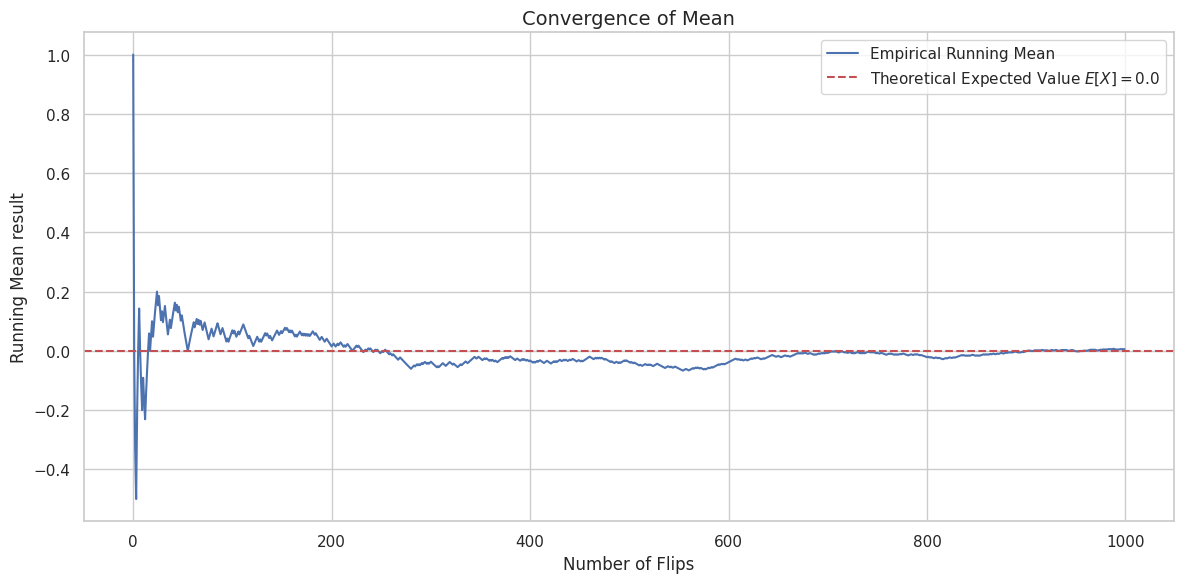

In [53]:
path: np.ndarray = sim_data[0]
mean: np.ndarray = np.cumsum(path) / np.arange(1, flips_per_simulations + 1)

# Plotting
plt.figure()
plt.plot(mean, label="Empirical Running Mean")
plt.axhline(y=0.0, color="r", linestyle="--", label="Theoretical Expected Value $E[X] = 0.0$")
plt.title("Convergence of Mean")
plt.xlabel("Number of Flips")
plt.ylabel("Running Mean result")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## 3. Visualizing the Distribution of Outcomes (Central Limit Theorem)

Visualization of the final distribution of balances. This distribution should be Gaussian (Central Limit Theorem).

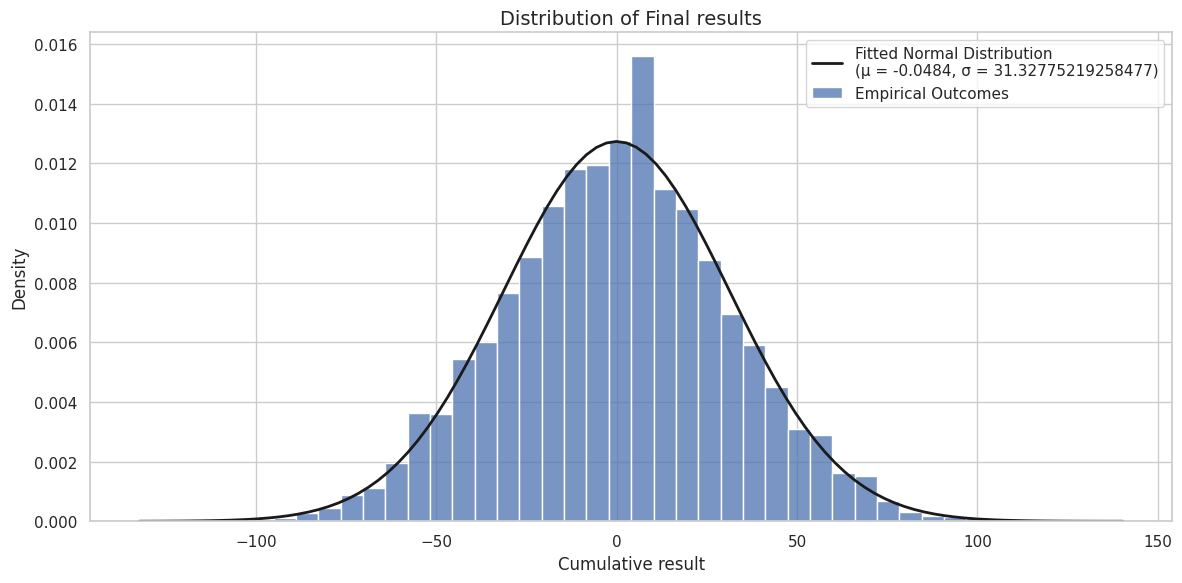

Empirical Mean:                -0.0484, theorical value is 0.
Empirical Standard Deviation:  31.32775219258477


In [56]:
# Calculate final return for each simulation with type annotations
final_results: np.ndarray = np.sum(sim_data, axis=1)

# Fit a normal distribution curve to the empirical data
mu: float
std: float
mu, std = norm.fit(final_results)

# Plotting distribution
plt.figure()
sns.histplot(final_results, bins=40, stat="density", label="Empirical Outcomes")

# Plotting normal curve
xmin: float
xmax: float
xmin, xmax = plt.xlim()
x: np.ndarray = np.linspace(xmin, xmax, 100)
p: np.ndarray = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Fitted Normal Distribution\n(\u03bc = {mu}, \u03c3 = {std})')

plt.title("Distribution of Final results")
plt.xlabel("Cumulative result")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Empirical Mean:                {np.mean(final_results)}, theorical value is 0.")
print(f"Empirical Standard Deviation:  {np.std(final_results)}")